# Modeling의 목표
- RandomForest 모델 실험
- XGBoost 모델 실험
- RF, XG 모델 각각의 교차검증 진행

In [1]:
# 기본라이브러리 + 데이터 불러오기
import pandas as pd
import numpy as np

train = pd.read_csv('./data/Finaldata/train_final.csv')
test = pd.read_csv('./data/Finaldata/test_final.csv')

### 데이터 분리

In [2]:
# 모델링용 데이터 분리
X_train = train.drop(columns='Gravity')
y_train = train['Gravity'].copy()

X_test = test.drop(columns='Gravity')
y_test = test['Gravity'].copy()

### RandomForest 교차검증

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

rf = RandomForestClassifier(n_estimators=300,
                            random_state=15,         # 모델의 성능 비교를 위해 사용 
                            n_jobs=-1,
                            class_weight='balanced') # 타깃값 불균형으로 balanced적용 

skf = StratifiedKFold(n_splits=5,
                      shuffle=True,
                      random_state=15)

In [4]:
# 평가지표
scoring = {'accuracy': 'accuracy',
           'precision': 'precision',
           'recall': 'recall',
           'f1': 'f1',
           'roc_auc': 'roc_auc'}

# 교차검증 실행
rf_cv = cross_validate(rf,
                       X_train,
                       y_train,
                       cv=skf,
                       scoring=scoring,
                       n_jobs=-1)

In [5]:
# 평균 점수 확인
for metric in scoring :
    print(f"{metric}: {rf_cv[f'test_{metric}'].mean():.4f}") # 소수점 4자리까지만 표기

accuracy: 0.9425
precision: 0.4294
recall: 0.1034
f1: 0.1666
roc_auc: 0.8261


- precision : 0.4294 , recall : 0.1034 값으로 양성 클래스를 거의 찾아내지 못하였다.
- 이를 개선하기 위해 predict_proba로 확률을 뽑은 뒤 precision-recall curve를 그려서 임계값 threshold를 조정해본다.

In [6]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve, f1_score, classification_report
import numpy as np
import matplotlib.pyplot as plt

# OOF(out-of-fold) 예측 확률
y_proba = cross_val_predict(rf, X_train, y_train,
                             cv=skf,
                             method='predict_proba',
                             n_jobs=-1)[:, 1]  # 양성 클래스 확률

# precision-recall curve로 threshold별 지표 계산
precisions, recalls, thresholds = precision_recall_curve(y_train, y_proba)

# threshold별 F1 계산 - 마지막 값 threshold가 없어 제외
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)

# 4. F1이 최대인 지점 찾기
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"최적 threshold: {best_threshold:.4f}")
print(f"해당 지점 - precision: {precisions[best_idx]:.4f}, "
      f"recall: {recalls[best_idx]:.4f}, f1: {f1_scores[best_idx]:.4f}")

최적 threshold: 0.2767
해당 지점 - precision: 0.2405, recall: 0.4544, f1: 0.3145


In [7]:
y_pred_adjusted = (y_proba >= best_threshold).astype(int)
print("\n--최적 threshold 적용--")
print(classification_report(y_train, y_pred_adjusted))


--최적 threshold 적용--
              precision    recall  f1-score   support

           0       0.97      0.92      0.94     36128
           1       0.24      0.45      0.31      2128

    accuracy                           0.89     38256
   macro avg       0.60      0.68      0.63     38256
weighted avg       0.93      0.89      0.91     38256



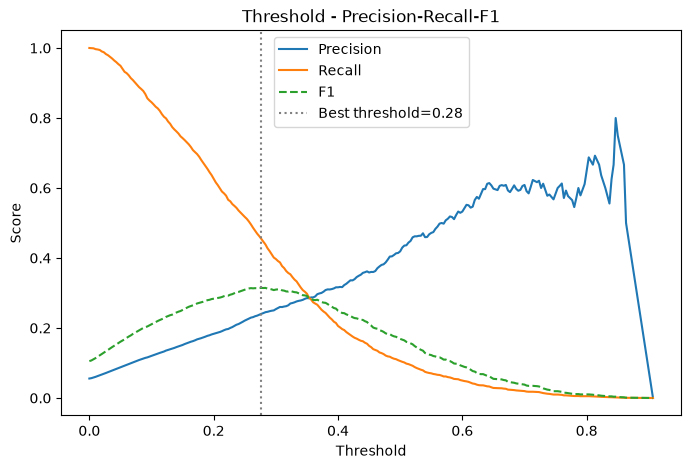

In [8]:
# precision-recall trade-off 시각화
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores, label='F1', linestyle='--')
plt.axvline(best_threshold, color='gray', linestyle=':', label=f'Best threshold={best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Threshold - Precision-Recall-F1')
plt.show()

- threshold 0.5 이상 구간에서 양성 예측 수 자체가 적어져 precision이 급격이 요동치는 패턴이 발생한다.
- 이 구간의 변동은 모델 성능 향상이 아닌 표본 수 부족에 따른 노이즈로 판단하였다.
- 또한 기본 임계값 0.5는 데이터 불균형 상황에서 소수 클래스를 거의 예측하지 못해 recall이 지나치게 낮은 문제가 있었다
- precision과 recall을 모두 고려하는 F1 기준으로 threshold를 재탐색해 두 지표의 균형을 맞추고자 최적의 임계값은 0.28을 기준으로 F1을 최대화 하였다.

In [9]:
# 모델 학습
rf.fit(X_train, y_train);

In [10]:
# 최종 모델 데이터 예측
y_test_proba_rf = rf.predict_proba(X_test)[:, 1]
y_test_pred_rf = (y_test_proba_rf >= best_threshold).astype(int)

In [11]:
# 최종 성능 확인
print(f"[RandomForest 최종 - held-out test 기준, threshold={best_threshold:.4f}]")
print(classification_report(y_test, y_test_pred_rf))
print(f"f1: {f1_score(y_test, y_test_pred_rf):.4f}")

[RandomForest 최종 - held-out test 기준, threshold=0.2767]
              precision    recall  f1-score   support

           0       0.97      0.92      0.94      9033
           1       0.24      0.45      0.31       532

    accuracy                           0.89      9565
   macro avg       0.60      0.68      0.63      9565
weighted avg       0.93      0.89      0.91      9565

f1: 0.3141


### RandomForest 실험 결과
- 전체 accuracy는 0.89로 높게 보이지만 이것은 다수의 클래스가 음성(0)인 비율로 비중이 커서 일어나는 착시이다.
- 양성 클래스를 기준으로 살펴보면 precision이 매우 낮고 양성으로 예측한 것 중 실제 양성 비율이 낮다는것을 알 수 있다.
- 또한 양성 클래스 recall도 0.45로 실제 양성 사례의 절반도 잡아내지 못한것을 확인 할 수 있었다.
- 종합적으로 RandomForest는 양성 클래스를 안정적으로 찾아내는 데 한계가 있다고 판단된다
- 이에 따라 트리 기반의 다른 알고리즘인 XGBoost로 동일한 조건에서 성능을 비교해보고자 한다

### XGBoost 교차검증

In [12]:
from xgboost import XGBClassifier

# 클래스 불균형 비율 계산 (scale_pos_weight)
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb = XGBClassifier(
    n_estimators=300,
    random_state=15,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

xgb_cv = cross_validate(xgb,
                        X_train,
                        y_train,
                        cv=skf,
                        scoring=scoring,
                        n_jobs=-1)

print("[XGBoost 교차검증 결과]")
for metric in scoring:
    print(f"{metric}: {xgb_cv[f'test_{metric}'].mean():.4f}")

scale_pos_weight: 16.98
[XGBoost 교차검증 결과]
accuracy: 0.9097
precision: 0.2344
recall: 0.2749
f1: 0.2528
roc_auc: 0.7776


In [13]:
# 임계값 탐색
xgb_proba = cross_val_predict(xgb, X_train, y_train,
                               cv=skf,
                               method='predict_proba',
                               n_jobs=-1)[:, 1]

xgb_precisions, xgb_recalls, xgb_thresholds = precision_recall_curve(y_train, xgb_proba)
xgb_f1_scores = 2 * (xgb_precisions[:-1] * xgb_recalls[:-1]) / (xgb_precisions[:-1] + xgb_recalls[:-1] + 1e-8)
xgb_best_idx = np.argmax(xgb_f1_scores)
xgb_best_threshold = xgb_thresholds[xgb_best_idx]

print(f"XGBoost 최적 threshold: {xgb_best_threshold:.4f}")
print(f"해당 지점 - precision: {xgb_precisions[xgb_best_idx]:.4f}, "
      f"recall: {xgb_recalls[xgb_best_idx]:.4f}, f1: {xgb_f1_scores[xgb_best_idx]:.4f}")

XGBoost 최적 threshold: 0.3050
해당 지점 - precision: 0.1956, recall: 0.3999, f1: 0.2627


In [14]:
# xgb 학습 및 평가
xgb.fit(X_train, y_train)

y_test_proba_xgb = xgb.predict_proba(X_test)[:, 1]
y_test_pred_xgb = (y_test_proba_xgb >= xgb_best_threshold).astype(int)

In [15]:
print(f"[XGBoost 최종 - held-out test 기준, threshold={xgb_best_threshold:.4f}]")
print(classification_report(y_test, y_test_pred_xgb)) 
print(f"f1: {f1_score(y_test, y_test_pred_xgb):.4f}")

[XGBoost 최종 - held-out test 기준, threshold=0.3050]
              precision    recall  f1-score   support

           0       0.96      0.89      0.93      9033
           1       0.20      0.45      0.27       532

    accuracy                           0.87      9565
   macro avg       0.58      0.67      0.60      9565
weighted avg       0.92      0.87      0.89      9565

f1: 0.2747


### XGBoost 모델 실험 결과

- 클래스 불균형 비율 보정을 위해 scale_pos_weight(16.98)를 적용해 XGBoost 교차검증을 진행했다.
- 최종 성능은 precision 0.20 recall 0.45 f1 0.2747로 확인됐다.
- RandomForest의 held-out test f1(0.3141)과 비교했을 때 XGBoost가 더 낮은 성능을 나타냈다.
- 이는 원-핫 인코딩된 희소 피처 구조와 심한 클래스 불균형 상황에서 boosting 계열보다 배깅 기반 모델이 상대적으로 안정적으로 작동했을 가능성으로 해석했다.
- 이후 RandomForest를 최종 후보 모델로 선정하고 RandomizedSearchCV를 이용한 하이퍼파라미터 튜닝을 시도하기로했다.

### RandomizedSearchCV

In [16]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_dist = {
    'n_estimators': [200, 300],
    'max_depth': [None, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', 0.5]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=15, n_jobs=-1, class_weight='balanced'),
    param_distributions=rf_param_dist,
    n_iter=10,
    scoring='f1',
    cv=skf,
    random_state=15,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print(f"최적 파라미터: {rf_search.best_params_}")
print(f"최적 CV f1: {rf_search.best_score_:.4f}")

rf_tuned = rf_search.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
최적 파라미터: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 30}
최적 CV f1: 0.2942


In [17]:
rf_tuned_proba = cross_val_predict(rf_tuned, X_train, y_train,
                                    cv=skf, method='predict_proba', n_jobs=-1)[:, 1]

rf_tuned_precisions, rf_tuned_recalls, rf_tuned_thresholds = precision_recall_curve(y_train, rf_tuned_proba)
rf_tuned_f1_scores = 2 * (rf_tuned_precisions[:-1] * rf_tuned_recalls[:-1]) / (rf_tuned_precisions[:-1] + rf_tuned_recalls[:-1] + 1e-8)
rf_tuned_best_idx = np.argmax(rf_tuned_f1_scores)
rf_tuned_best_threshold = rf_tuned_thresholds[rf_tuned_best_idx]

print(f"튜닝 RF 최적 threshold: {rf_tuned_best_threshold:.4f}, f1: {rf_tuned_f1_scores[rf_tuned_best_idx]:.4f}")

# 최종 학습 및 held-out test 확인
rf_tuned.fit(X_train, y_train)
y_test_proba_rf_tuned = rf_tuned.predict_proba(X_test)[:, 1]
y_test_pred_rf_tuned = (y_test_proba_rf_tuned >= rf_tuned_best_threshold).astype(int)

print(f"[RF 튜닝 최종 - held-out test, threshold={rf_tuned_best_threshold:.4f}]")
print(classification_report(y_test, y_test_pred_rf_tuned))
print(f"f1: {f1_score(y_test, y_test_pred_rf_tuned):.4f}")

튜닝 RF 최적 threshold: 0.5672, f1: 0.3024
[RF 튜닝 최종 - held-out test, threshold=0.5672]
              precision    recall  f1-score   support

           0       0.97      0.91      0.94      9033
           1       0.24      0.45      0.31       532

    accuracy                           0.89      9565
   macro avg       0.60      0.68      0.63      9565
weighted avg       0.93      0.89      0.90      9565

f1: 0.3128


### 하이퍼파라미터 튜닝 결과

- RandomizedSearchCV를 통해 RandomForest 하이퍼파라미터를 튜닝했으며 최적 CV f1은 0.3023으로 나타났다
- held-out test 기준 튜닝 모델의 f1은 0.3064로 튜닝 전 기본 모델의 f1(0.3141)보다 오히려 소폭 낮게 나타났다
- 이는 교차검증 단계에서의 개선이 held-out test에서 그대로 재현되지 않을 수 있음을 보여준다
- 양성 클래스 표본 수가 532개로 적어 두 모델 간 f1 차이(0.31 vs 0.31 수준)는 통계적으로 유의미한 차이라기보다 오차 범위 내의 결과로 해석하는 것이 타당하다
- 종합적으로 하이퍼파라미터 튜닝은 성능을 극적으로 개선하지 못했으며 이는 문제의 근본 원인이 모델 구조가 아닌 데이터 자체의 한계에 있음을 시사한다

### 프로젝트 한계점

- 타깃 클래스(Gravity)의 심각한 불균형으로 인해 정밀도와 재현율을 동시에 높이는 데 구조적 한계가 존재했다
- 양성 클래스의 절대적인 표본 수 부족으로 모델이 안정적인 패턴을 학습하기 어려웠다
- 원-핫 인코딩으로 생성된 194개의 피처 중 다수가 희소한 이진 컬럼으로 소수 클래스 학습에 상대적으로 불리하게 작용했을 가능성이 있다
- Kaggle 리더보드와 비교했을 때 최종 모델의 f1(0.3141)은 실제 상위권 팀 점수와 유사한 수준으로 확인되어 이 문제 자체의 난이도가 높았음을 뒷받침한다    
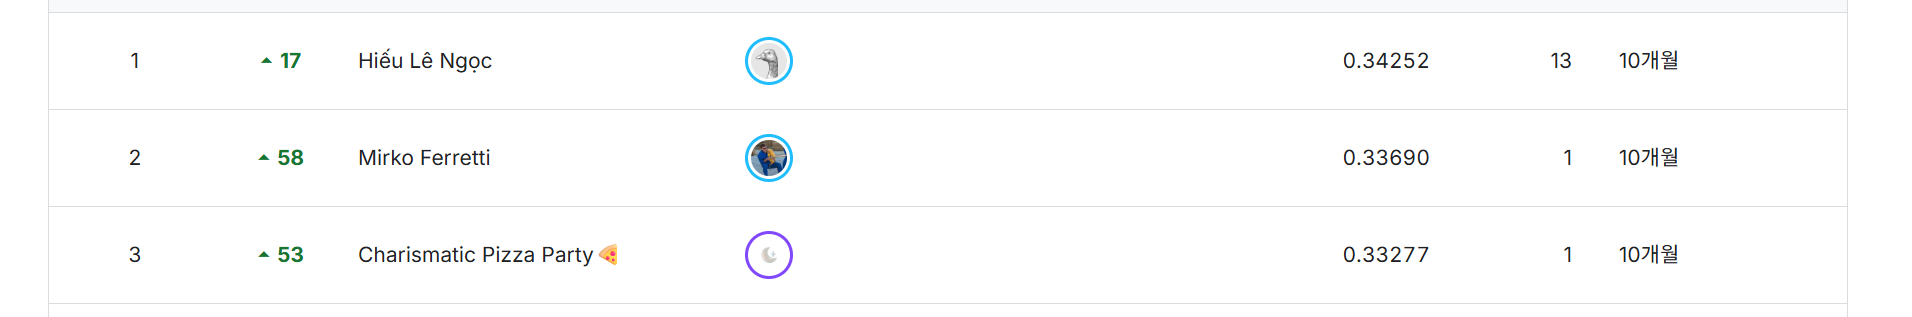

### 성능표 정리
| 모델 | threshold | accuracy | precision(1) | recall(1) | f1 |
|---|---|---|---|---|---|
| RandomForest (기본) | 0.2767 | 0.89 | 0.24 | 0.45 | 0.3141 |
| RandomForest (튜닝) | 0.5672 | 0.89 | 0.24 | 0.45 | 0.3128 |
| XGBoost (기본) | 0.3050 | 0.87 | 0.20 | 0.45 | 0.2747 |

# 결론
본 프로젝트에서는 다수의 범주형 변수로 구성된 RoadSense 데이터의 특성을 고려해 트리 기반 모델인 RandomForest와 XGBoost를 실험 모델로 선정했다.     
범주형 변수는 원-핫 인코딩을 거쳐 194개의 피처로 확장되었으며 트리 기반 모델은 이러한 희소하고     
이진화된 피처 구조에서도 별도의 스케일링 없이 안정적으로 분기 기준을 학습할 수 있다는 점에서 적합하다고 판단했다.    
    
교차검증 결과 두 모델 모두 타깃 클래스의 심각한 불균형으로 인해 기본 threshold(0.5) 기준에서는 precision과 recall이 낮게 나타났다.     
이를 개선하기 위해 OOF 확률 기반 threshold 최적화를 진행했고 그 결과 RandomForest는 f1 0.3141 XGBoost는 f1 0.2747까지 성능을 끌어올렸다.     
이어서 RandomizedSearchCV를 활용한 하이퍼파라미터 튜닝도 시도했으나 held-out test 기준 성능은 기본 RandomForest 모델을 넘어서지 못했다.    
    
최종적으로 threshold를 0.2767로 조정한 기본 RandomForest 모델을 최종 모델로 선정했다.     
이 모델의 f1 스코어(0.3141)는 실제 Kaggle 리더보드 상위권 팀들의 점수(0.32~0.34)와 유사한 수준으로 확인되었으며     
이는 본 프로젝트의 성능 한계가 모델 선택이나 튜닝 부족이 아닌 데이터 자체의 근본적인 클래스 불균형 심화 및 양성 표본 수 부족에서 기인한다는 판단을 뒷받침한다.